In [30]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Literal
from langchain_ollama import ChatOllama
from pydantic import BaseModel,Field

In [31]:
class state(TypedDict):

    review : str 
    sentiment : str 

    issue_type : str 
    tone : str 
    negative_response : str
    positive_response : str


In [32]:
model=ChatOllama(
    model='llama3.2:3b',
    temperature=0.8,
    reasoning=False
)
class strutured_schema(BaseModel):

    sentiment : Literal['pos','neg']
    tone : Literal['harsh','moderate','light']
    issue_type : Literal['bad_product','bad_service','bad_customer_support','other']

strutured_model=model.with_structured_output(strutured_schema)

def sentiment_finder(state:state) ->Literal['pos','neg']:
    prompt=f'give the sentiment of given text pos or neg ->{state['review']}'
    result=strutured_model.invoke(prompt) 
    return {'sentiment':result.sentiment}



In [33]:
def digo_finder(state:state):
    prompt=f'analysis the tone and issue_type of the given review ->{state["review"]}'
    result=strutured_model.invoke(prompt)
    return {'tone':result.tone ,'issue_type':result.issue_type}

In [44]:
def negative_response(state:state):
    prompt=f'genrated the response for handling negative resopse for following review ->{state["review"]}'
    result=model.invoke(prompt)
    return {'negative_response' : result.content }

In [35]:
def positive_responses(state:state):
    prompt=f'genrate the response for handling postive review for following review->{state["review"]}'
    result=model.invoke(prompt)
    return {'positive_response': result.content}

In [36]:
def check_sentiment(state:state)-> Literal['run_digo','positive_response']:
    if state['sentiment']=='pos':
        return 'positive_response'
    else:
        return 'run_digo'

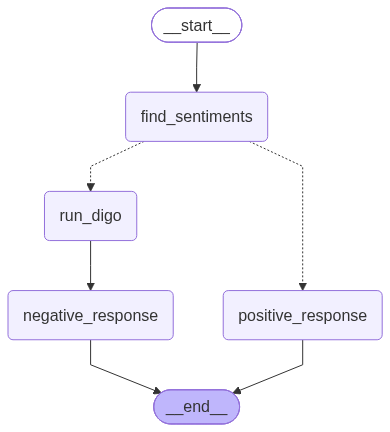

In [49]:
graph=StateGraph(state)

graph.add_node("find_sentiments",sentiment_finder)
graph.add_node('run_digo',digo_finder)
graph.add_node('negative_response',negative_response)
graph.add_node('positive_response',positive_responses)

graph.add_edge(START,'find_sentiments')
graph.add_conditional_edges("find_sentiments",check_sentiment)
graph.add_edge('run_digo','negative_response')
graph.add_edge('negative_response',END)
graph.add_edge('positive_response',END)

workflow=graph.compile()

workflow


In [47]:
intial_state={'review':"your service is not so goood  "}
workflow.invoke(intial_state)

{'review': 'your service is not so goood  ',
 'sentiment': 'neg',
 'issue_type': 'bad_service',
 'tone': 'moderate',
 'negative_response': 'Here\'s a generated response to handle a negative review:\n\n**Response**\n\n"Dear [Reviewer\'s Name],\n\nThank you for taking the time to share your feedback about our service. We apologize that we didn\'t meet your expectations and regret that you feel our service wasn\'t good enough.\n\nWe\'re truly sorry to hear that your experience with us was disappointing. Please know that we take all feedback seriously and are committed to continually improving our services to provide the best possible experience for our customers.\n\nCan you please contact us directly so we can understand more about what specifically didn\'t meet your expectations? This will help us to identify areas where we can make improvements.\n\nYour feedback is invaluable in helping us to grow and improve. We appreciate your honesty and look forward to the opportunity to serve you b